### Datos sintéticos 
### Librería SDV
*Fecha: 05/06/2026*

*Autor: Luis Alberto García Lezama*

In [1]:
# Importamos librerías básicas
import pandas as pd
import numpy as np
import random

In [2]:
# Importamos librerías para datos sintéticos 
import sdv
import sdmetrics

In [3]:
# Importamos sublibrerías para la generación de datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [4]:
# Importamos sublibrerías para la evaluación de los datos
from sdmetrics.reports.single_table import QualityReport

In [5]:
print("SDV: ", sdv.__version__)
print("SDMetetrics: ", sdmetrics.__version__)

SDV:  1.37.0
SDMetetrics:  0.28.0


In [6]:
# Crear una tabla de datos REAL como base para la generación de Datos Sintéticos
dfClientes = pd.DataFrame(
    {
        "cliente_id" : [1,2,3,4,5,6,7,8,9,10],
        "edad" : [17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual" : [1800, 2000, 2500, 15000, 18000, 35000, 7000, 15000, 4000,5000],
        "ciudades" : ["Potrero Nuevo", "Atoyac", "Cuichapa", "Córdoba", "Cuitláhuac", "Orizaba", "Paraje", "Yanga", "Tierra Blanca", "Calcahualco"]
    }
)

In [7]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudades
0,1,17,1800,Potrero Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Córdoba
4,5,32,18000,Cuitláhuac
5,6,42,35000,Orizaba
6,7,70,7000,Paraje
7,8,28,15000,Yanga
8,9,23,4000,Tierra Blanca
9,10,22,5000,Calcahualco


### Obtener los metadata del DataFrame generado

In [8]:
# Creamos una instancia de SingleTableMetadata
metadata = SingleTableMetadata()

In [9]:
metadata.detect_from_dataframe(
    data= dfClientes
)

In [10]:
metadata.to_dict()

{'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudades': {'sdtype': 'categorical'}},
 'primary_key': 'cliente_id',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

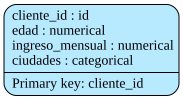

In [11]:
metadata.visualize()

### Entrenar el modelo de datos sintéticos
*Un sinthetisizer es el encargado de generar los datos sintéticos* 

In [13]:
# Le psamos los metadatos
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

C:\Users\luisi\anaconda3\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\Users\luisi\anaconda3\Lib\site-packages\sdv\single_table\base.py:138: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [14]:
# Entrenamos con los datos "REALES"
sintetizador.fit(
    dfClientes
)

In [16]:
# Generamos los datos sintéticos
dfClientes_falsos = sintetizador.sample(
    num_rows=200
)

In [17]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudades
0,1,17,1800,Potrero Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Córdoba
4,5,32,18000,Cuitláhuac
5,6,42,35000,Orizaba
6,7,70,7000,Paraje
7,8,28,15000,Yanga
8,9,23,4000,Tierra Blanca
9,10,22,5000,Calcahualco


In [19]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudades         200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [20]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,10530.000000
std,3.02765,16.063762,10507.568701
min,1.00000,17.000000,1800.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,6000.000000
75%,7.75000,31.000000,15000.000000
max,10.00000,70.000000,35000.000000


In [22]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.040000,10660.795000
std,4.707538e+06,12.578134,9158.859748
min,4.660500e+04,18.000000,2000.000000
25%,5.085226e+06,18.000000,2703.250000
50%,9.212590e+06,20.000000,7945.500000
75%,1.279456e+07,30.000000,16188.500000
max,1.677377e+07,70.000000,35000.000000


### Evaluamos los datos para validar
1. Parecido entre las columnas (Columns Shapes Scores)
2. Similitud en las relaciones de las columnas (Evaluating Column Per Trends)
3. Evaluación del dataset original

In [23]:
# Evaluamos la calidad de los datos 
# Cramos una instancia de QualityReport
reporte = QualityReport()

In [25]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████████████████████████████████████████████████| 4/4 [00:00<00:00, 174.99it/s]|
Column Shapes Score: 78.83%

(2/2) Evaluating Column Pair Trends: |█████████████████████████████████████████████████| 6/6 [00:00<00:00, 105.95it/s]|
Column Pair Trends Score: 27.75%

Overall Score (Average): 53.29%



### Puntos de referencia

|Score  | Interpretación  |
|-------|-----------------|
|1    | Identicas |
|0.9  | Muy Similar |
|0.7  | Similar     |
|0.6  | Diferencias visibles |
|<0.5 | Muy diferentes       | 